# Battery-siting ranking vs. |nodal congestion premium| — **bus-wise** (2025-hourly)

Bus-wise version using the real PyPSA-Eur partition from `resources/`:

1. Rank **every** battery location in `grid_siting_scores_20260629_155333.csv` by
   `dV_proxy_eur_per_year` (rank 1 = best site).
2. Take the **489 German transmission buses** in `resources/.../networks/base_s.nc`
   (the pre-cluster full-resolution network). Each fine bus is mapped to its solved
   node via `busmap_base_s_20.csv`, and inherits that node's **|congestion premium|**
   from the PyPSA-Eur 2025-hourly run.
3. Give each fine bus its siting value (nearest siting cell, median snap ≈ 4 km) and
   compare the two **bus-wise** orderings across all 489 buses.

Why bus-wise: prices exist only at the 20 solved nodes, but the busmap lets us weight
each node by its true electrical extent (number of transmission buses) and use the
exact model partition instead of a nearest-node approximation.

In [1]:
import netCDF4 as nc, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import spearmanr, kendalltau
plt.rcParams['figure.dpi']=110; plt.rcParams['font.size']=10
BASE_S = "../resources/de-nodal-2025-hourly/networks/base_s.nc"
BUSMAP = "../resources/de-nodal-2025-hourly/busmap_base_s_20.csv"
NODE   = "nodal_vs_siting_comparison_2025.csv"
SITE   = "../battery_siting_score/out/grid_siting_scores_20260629_155333.csv"
SCORE_COL = "dV_proxy_eur_per_year" 

## 1. Relative ranking of ALL battery locations (fine siting grid)

In [2]:
sit = pd.read_csv(SITE).sort_values(SCORE_COL, ascending=False).reset_index(drop=True)
sit['site_rank']=np.arange(1,len(sit)+1); sit['site_percentile']=sit[SCORE_COL].rank(pct=True)
sit.to_csv("battery_location_ranking_full.csv", index=False)
print(f"ranked {len(sit)} battery locations -> battery_location_ranking_full.csv")
sit[['site_rank','lon','lat','bus_idx',SCORE_COL,'site_percentile']].head(8)

ranked 4593 battery locations -> battery_location_ranking_full.csv


,site_rank,lon,lat,bus_idx,dV_proxy_eur_per_year,site_percentile
0,1,11.0,51.2,383,1.623798e+07,0.999565
1,2,10.9,51.2,383,1.623798e+07,0.999565
2,3,11.0,51.1,383,1.623798e+07,0.999565
3,4,11.1,51.1,383,1.623798e+07,0.999565
4,5,11.2,51.0,383,1.623798e+07,0.999565
5,6,13.2,51.3,325,1.601882e+07,0.995319
6,7,13.0,51.3,325,1.601882e+07,0.995319
7,8,13.3,51.3,325,1.601882e+07,0.995319


## 2. Build the 489 German transmission buses (base_s) with node + congestion premium

In [3]:
ds=nc.Dataset(BASE_S)
rs=lambda n:(list(nc.chartostring(ds.variables[n][:])) if ds.variables[n][:].dtype.kind in 'SU' else ds.variables[n][:])
bus=pd.DataFrame({'name':[str(b) for b in rs('buses_i')],'x':rs('buses_x'),'y':rs('buses_y'),
                  'country':[str(c) for c in rs('buses_country')]}); ds.close()
bus=bus[bus.country=='DE'].copy()
bm=pd.read_csv(BUSMAP); bus=bus.merge(bm,on='name',how='left')            # fine bus -> node
nod=pd.read_csv(NODE); nod['abs_congestion']=nod['congestion_premium'].abs()
bus=bus.merge(nod[['bus','congestion_premium','abs_congestion']],left_on='busmap',right_on='bus',how='left')
print(f"DE fine buses: {len(bus)}  |  matched to node: {bus.busmap.notna().sum()}")
bus.busmap.value_counts().rename('n_buses_per_node')

DE fine buses: 489  |  matched to node: 489


busmap
DE0 2AC    131
DE0 7AC     62
DE0 5AC     61
DE0 0AC     53
DE0 9AC     42
DE0 3AC     42
DE0 1AC     30
DE0 4AC     28
DE0 8AC     21
DE0 6AC     19
Name: n_buses_per_node, dtype: int64

## 3. Give each bus its siting value (nearest siting cell)

In [4]:
tree=cKDTree(sit[['lon','lat']].values)
d,idx=tree.query(bus[['x','y']].values,k=1)
bus['sit_dV']=sit[SCORE_COL].values[idx]; bus['snap_km']=d*111.0
bus=bus.dropna(subset=['abs_congestion','sit_dV']).reset_index(drop=True)
# bus-wise ranks (1 = best / most divergent)
bus['siting_rank']    =bus['sit_dV'].rank(ascending=False,method='average')
bus['congestion_rank']=bus['abs_congestion'].rank(ascending=False,method='average')
print(f"buses compared: {len(bus)}  |  median snap {bus.snap_km.median():.1f} km, p90 {bus.snap_km.quantile(.9):.1f} km")
bus[['name','busmap','x','y','sit_dV','siting_rank','abs_congestion','congestion_rank']].head(8)

buses compared: 489  |  median snap 4.3 km, p90 6.1 km


,name,busmap,x,y,sit_dV,siting_rank,abs_congestion,congestion_rank
0,relation/17591073-220,DE0 7AC,8.501915,49.444941,5.293042e+06,315.5,0.167,372.0
1,virtual_relation/1109593:b:1-380,DE0 2AC,7.369901,51.586949,8.577868e+06,150.5,0.167,372.0
2,virtual_relation/1141616:b:1-380,DE0 3AC,13.679807,52.584688,8.570949e+06,153.5,0.434,205.5
3,virtual_relation/13073144:1-220,DE0 1AC,11.638697,52.268899,1.363974e+07,24.0,0.395,241.5
4,virtual_relation/14514424:c:1-380,DE0 5AC,7.748465,52.288944,6.831458e+06,241.5,0.456,154.0
5,virtual_relation/145510:b:1-380,DE0 3AC,12.613200,53.588184,8.962638e+06,130.0,0.434,205.5
6,virtual_relation/1641702:b:1-380,DE0 7AC,8.439150,50.059172,8.764838e+06,141.0,0.167,372.0
7,virtual_relation/18799873:a:0-220,DE0 7AC,8.490964,49.245026,6.828801e+06,243.0,0.167,372.0


## 4. Do the two orderings agree? (bus-wise, n=489)

In [5]:
rho,ps=spearmanr(bus.sit_dV,bus.abs_congestion)
tau,pk=kendalltau(bus.sit_dV,bus.abs_congestion)
print(f"Spearman(sit_dV, |congestion premium|) = {rho:+.3f}  (p={ps:.2e})")
print(f"Kendall  tau                           = {tau:+.3f}  (p={pk:.2e})")
# top-decile best-site overlap
f=0.10; st=bus.sit_dV>=bus.sit_dV.quantile(1-f); ct=bus.abs_congestion>=bus.abs_congestion.quantile(1-f)
inter=int((st&ct).sum()); exp=f*f*len(bus)
print(f"top-10% overlap: {inter} buses  (lift vs random = {inter/exp:.2f}x, Jaccard={inter/int((st|ct).sum()):.3f})")

Spearman(sit_dV, |congestion premium|) = -0.140  (p=1.93e-03)
Kendall  tau                           = -0.108  (p=1.05e-03)
top-10% overlap: 1 buses  (lift vs random = 0.20x, Jaccard=0.008)


## 5. Graphs

### 5a. Maps — siting value vs |congestion premium| across the 489 buses

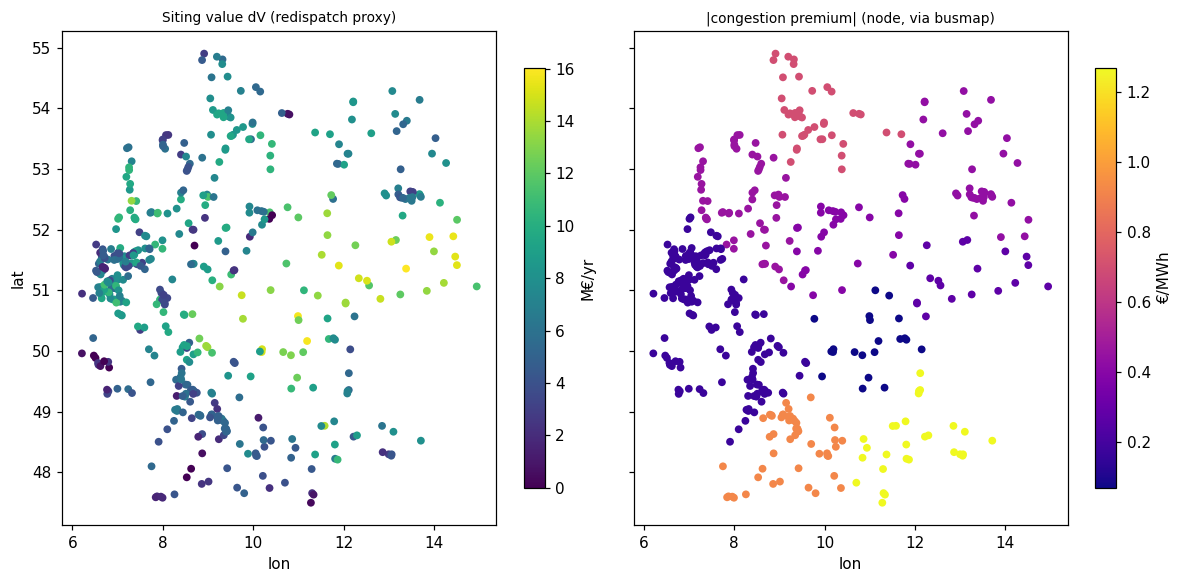

In [6]:
fig,ax=plt.subplots(1,2,figsize=(11,5.4),sharex=True,sharey=True)
for a,col,cmap,ttl,lab in [(ax[0],'sit_dV','viridis','Siting value dV (redispatch proxy)','M€/yr'),
                           (ax[1],'abs_congestion','plasma','|congestion premium| (node, via busmap)','€/MWh')]:
    v=bus[col]/1e6 if col=='sit_dV' else bus[col]
    sc=a.scatter(bus.x,bus.y,c=v,cmap=cmap,s=26,edgecolor='none'); a.set_title(ttl,fontsize=9)
    a.set_xlabel('lon'); fig.colorbar(sc,ax=a,label=lab,shrink=.85)
ax[0].set_ylabel('lat'); plt.tight_layout(); plt.show()

### 5b. Rank–rank scatter (bus-wise)

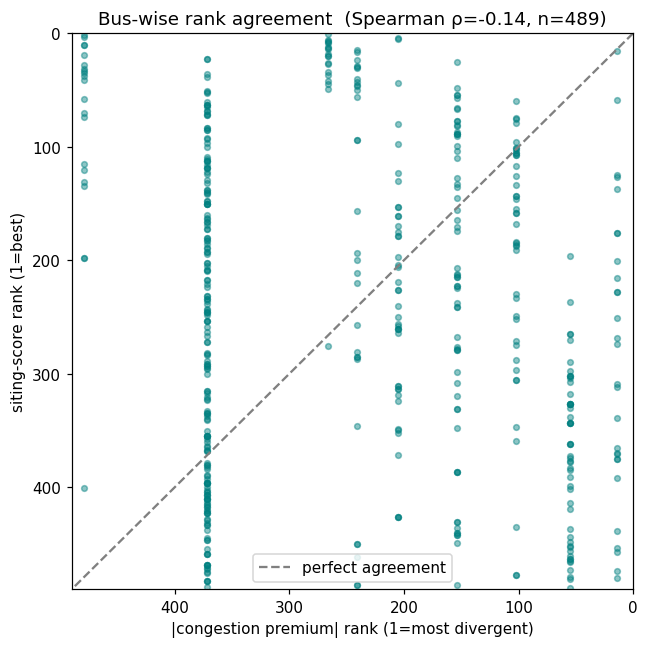

In [7]:
plt.figure(figsize=(6,6))
plt.scatter(bus.congestion_rank,bus.siting_rank,s=14,alpha=.45,c='teal')
lims=[0,len(bus)+1]; plt.plot(lims,lims,'--',c='grey',label='perfect agreement')
plt.xlim(lims); plt.ylim(lims); plt.gca().invert_xaxis(); plt.gca().invert_yaxis()
plt.xlabel('|congestion premium| rank (1=most divergent)'); plt.ylabel('siting-score rank (1=best)')
plt.title(f'Bus-wise rank agreement  (Spearman ρ={spearmanr(bus.sit_dV,bus.abs_congestion)[0]:+.2f}, n={len(bus)})')
plt.legend(); plt.tight_layout(); plt.show()

### 5c. Best-sites map — where the methods agree / disagree (top 10%)

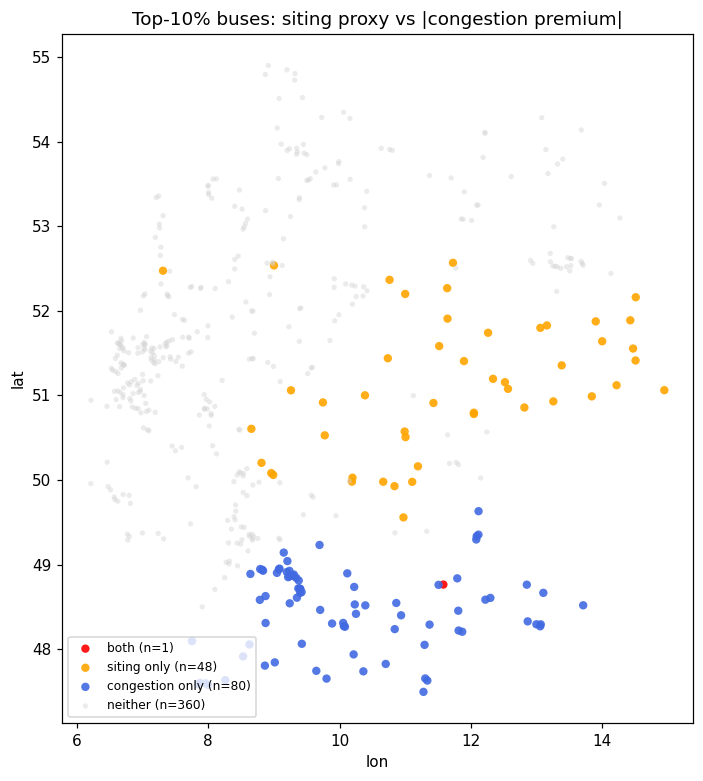

In [8]:
f=0.10; st=bus.sit_dV>=bus.sit_dV.quantile(1-f); ct=bus.abs_congestion>=bus.abs_congestion.quantile(1-f)
cat=np.where(st&ct,'both',np.where(st,'siting only',np.where(ct,'congestion only','neither')))
cols={'both':'red','siting only':'orange','congestion only':'royalblue','neither':'lightgrey'}
plt.figure(figsize=(6.5,7.2))
for k,c in cols.items():
    m=cat==k; plt.scatter(bus.x[m],bus.y[m],c=c,s=30 if k!='neither' else 12,
                          label=f'{k} (n={int(m.sum())})',alpha=.9 if k!='neither' else .45,edgecolor='none')
plt.legend(fontsize=8,loc='lower left'); plt.xlabel('lon'); plt.ylabel('lat')
plt.title('Top-10% buses: siting proxy vs |congestion premium|'); plt.tight_layout(); plt.show()

## 6. Save the bus-wise comparison table

In [9]:
out=bus[['name','busmap','x','y','sit_dV','siting_rank','congestion_premium','abs_congestion','congestion_rank','snap_km']]
out.to_csv("ranking_comparison_siting_vs_abscongestion_2025_BUSWISE.csv", index=False)
print("saved -> ranking_comparison_siting_vs_abscongestion_2025_BUSWISE.csv  (%d buses)"%len(out))

saved -> ranking_comparison_siting_vs_abscongestion_2025_BUSWISE.csv  (489 buses)


## 7. Takeaway

- This is the **bus-wise** comparison over the 489 real German transmission buses,
  using the PyPSA-Eur `busmap` (exact model partition, not a nearest-node guess).
- Because the fine buses inherit their node's congestion premium, the |congestion|
  axis has 10 distinct levels while the siting axis is continuous — so the test asks
  whether buses in high-|congestion| *nodes* also score high on the siting proxy.
- The sign/size of the bus-wise Spearman in §4 is the headline. A weak-negative value
  means the redispatch siting proxy and the nodal price-level divergence reward
  **different** locations: siting favours redispatch/curtailment-heavy areas, whereas
  |congestion premium| is largest where the mean nodal price is furthest from the zonal
  mean (import-constrained load centres).